# 1. Defining the Problem.

We shall be solving the heat equation :

$$ u_t = \alpha u_{xx} $$

with the boundary conditions :

$$ u(0,t) = u(1,t) = 0 $$

For this we shall be fixing $\alpha = 0.1$ and generating many sets of initial conditions.

In [52]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(17)

# 2. Generating Data.

We shall be generating the initial conditions using the following recipe :

$$ u(x,0) = a(x) = \sum_{n=1}^{N_{modes}} A_n\sin(n\pi x) $$

where $ A_n \in \mathcal{U}(-1,1) $.

Further, the exact solutions corresponding to these initial conditions are :

$$ u(x,t) = \sum_{n=1}^{N_{modes}} A_n e^{-\alpha n^2\pi^2 t} \sin(n\pi x) $$

In [53]:
# constants and parameters
pi = torch.pi
alpha = 0.1
N_train = 1000
N_test = 200
N_modes = 20
N_x, N_t = 81,61
x_arr = torch.linspace(0.0,1.0,N_x)
t_arr = torch.linspace(0.0,1.0,N_t)

In [54]:
def input_output_functions(N_func, x_arr, t_arr, N_x, N_t, N_modes, A_coeff):
    x_mesh, t_mesh = torch.meshgrid(x_arr, t_arr,indexing='ij')
    input_points = torch.column_stack((x_mesh.flatten(),t_mesh.flatten()))
    a = torch.zeros((N_func,N_x))               # initial condition functions
    u = torch.zeros(N_func,N_x * N_t)      # complete solutions of all input functions
    for n in range(N_modes):
        a += torch.outer(A_coeff[:,n], torch.sin((n+1)*pi*x_arr))
        u += torch.outer(A_coeff[:,n], ((torch.exp(-alpha * pi**2 * (n+1)**2 * t_mesh) * torch.sin((n+1) * pi * x_mesh))).flatten())
    return a, u.reshape(N_func, N_x, N_t)

In [55]:
# testing the input-output generating function
a_test, u_test = input_output_functions(
    N_func=3,
    x_arr = x_arr,
    t_arr = t_arr,
    N_x = N_x,
    N_t = N_t,
    N_modes = 3,
    A_coeff = torch.tensor([[1.0, 0.0, 0.0],[0.0, 1.0, 0.0], [0.5, 0.7, 0.4]])
)

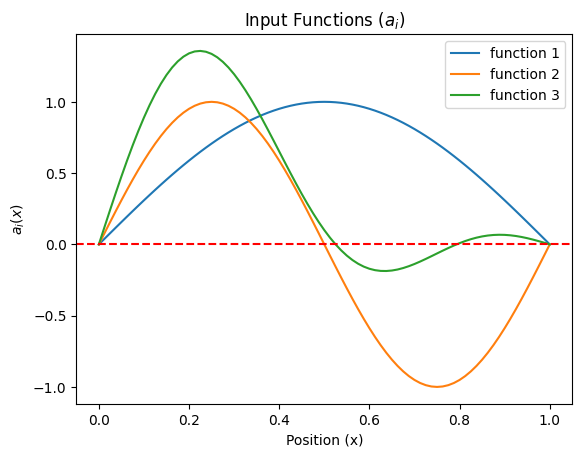

In [56]:
# visualisation
# input functions
plt.plot(x_arr, a_test[0],label = 'function 1')
plt.plot(x_arr, a_test[1],label = 'function 2')
plt.plot(x_arr, a_test[2],label = 'function 3')
plt.axhline(0,c='red',ls = '--')
plt.title('Input Functions ($a_i$)')
plt.legend()
plt.xlabel('Position (x)')
plt.ylabel("$a_i(x)$")
plt.show()

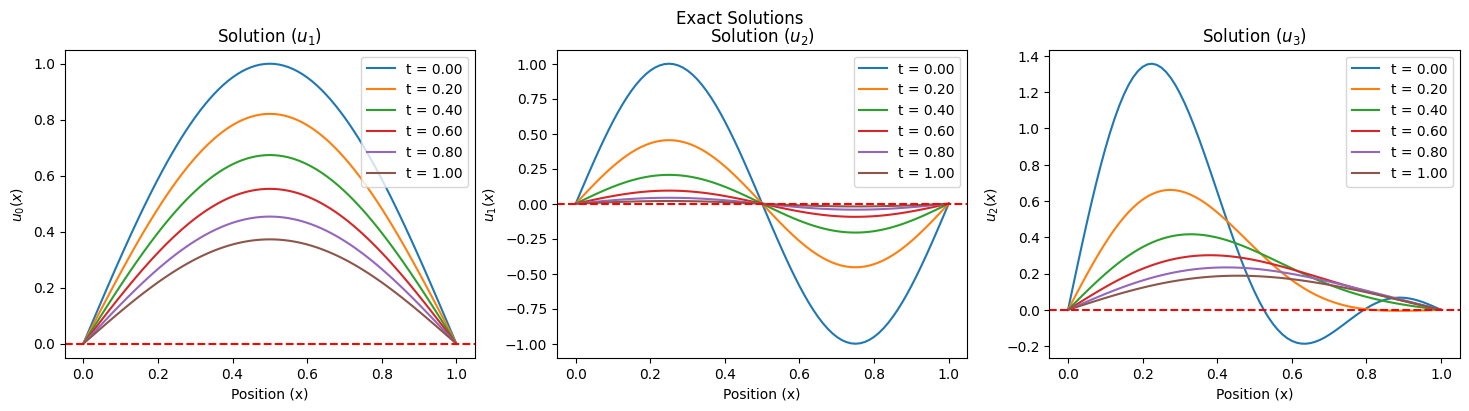

In [57]:
# visualisation
# output functions
plt.figure(figsize = (18,4))

for i in range(3):
    plt.subplot(1,3,i+1)
    N_times = 5
    base_index = int((N_t - 1)/N_times)
    for j in range(N_times + 1):
        plt.plot(x_arr, u_test[i,:, base_index * j],label = f't = {t_arr[base_index * j]:.02f}')
    plt.axhline(0,c='red',ls = '--')
    plt.title(f'Solution ($u_{i+1}$)')
    plt.legend()
    plt.xlabel('Position (x)')
    plt.ylabel(f"$u_{i}(x)$")
plt.suptitle("Exact Solutions")
plt.show()

Testing went good for data generating functions. Next we shall generate the data.

In [58]:
A_coeff_train = 2 * torch.rand((N_train, N_modes)) - 1
A_coeff_test = 2 * torch.rand((N_test, N_modes)) - 1
a_train, u_train = input_output_functions(N_train, x_arr, t_arr, N_x, N_t, N_modes, A_coeff_train)
a_test, u_test = input_output_functions(N_test, x_arr, t_arr, N_x, N_t, N_modes, A_coeff_test)

print("Data Shape Summary :\n")
print(f"Input Training Data : {a_train.shape}")
print(f"Solutions Training Data : {u_train.shape}")
print(f"Input Testing Data : {a_test.shape}")
print(f"Solutions Testing Data : {u_test.shape}")

Data Shape Summary :

Input Training Data : torch.Size([1000, 81])
Solutions Training Data : torch.Size([1000, 81, 61])
Input Testing Data : torch.Size([200, 81])
Solutions Testing Data : torch.Size([200, 81, 61])


# 3. Normalizing the Data.

In [69]:
a_train_norm = (a_train - torch.mean(a_train, axis = 0))/torch.std(a_train, axis = 0)

In [65]:
xxx = torch.tensor([[1,2,0], [3,6,9]],dtype = torch.float16)
print(xxx)
print(torch.mean(xxx, axis=0))

tensor([[1., 2., 0.],
        [3., 6., 9.]], dtype=torch.float16)
tensor([2.0000, 4.0000, 4.5000], dtype=torch.float16)
